In [5]:
print(true_values,sensor_readings)

[0, -1] [[-1975.0, -4288.0, -5458.0, -5402.0, -6188.0, -7549.0, -8376.0, -8540.0, -9501.0, -10154.0, -10886.0, -11803.0, -12088.0, -11444.0, -10512.0, -10182.0, -9895.0, -8797.0, -9357.0, -9700.0, -8903.0, -7176.0, -6108.0, -5639.0, -5684.0, -5780.0, -6085.0, -5041.0, -4434.0, -4900.0, -5229.0, -4751.0, -4370.0, -5342.0, -7121.0, -7617.0, -8142.0, -8023.0, -7289.0, -6546.0, -6495.0, -5906.0, -6584.0, -7372.0, -7651.0, -7212.0, -6884.0, -6723.0, -7069.0, -7098.0, -6823.0, -7195.0, -7744.0, -7706.0, -8253.0, -8958.0, -9239.0, -10193.0, -10958.0, -10848.0, -9988.0, -8114.0, -5455.0, -3137.0, -3232.0, -3177.0, -2929.0, -3283.0, -3648.0, -3460.0, -2376.0, -1809.0, -2017.0, -899.0, -1457.0, -1943.0, -3723.0, -5295.0, -3478.0, -629.0, 784.0, 56.0, -1680.0, -4222.0, -6194.0, -7444.0, -7919.0, -8068.0, -7831.0, -7247.0, -7183.0, -7585.0, -8388.0, -9194.0, -9309.0, -9343.0, -9695.0, -9876.0, -9102.0, -9479.0], [620.0, -834.0, -1218.0, -3320.0, -4148.0, -6530.0, -7107.0, -8275.0, -9295.0, -7750.0

### Mean, Standard Deviation, and Regression

Here we will calculate the mean standard deviation and regression line for the collected data

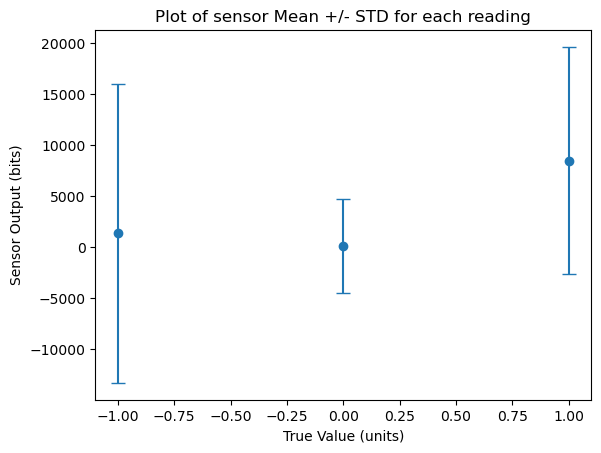

In [6]:
# Aggregate the data and plot with errorbars

mean_sensor_readings = np.mean(sensor_readings, axis=1)
std_sensor_readings = np.std(sensor_readings, axis=1)

plt.figure()
plt.title('Plot of sensor Mean +/- STD for each reading')
plt.xlabel('True Value (units)')
plt.ylabel('Sensor Output (bits)')
plt.errorbar(true_values,mean_sensor_readings, yerr = std_sensor_readings, fmt='None', capsize=5)
plt.scatter(true_values,mean_sensor_readings)
plt.show()



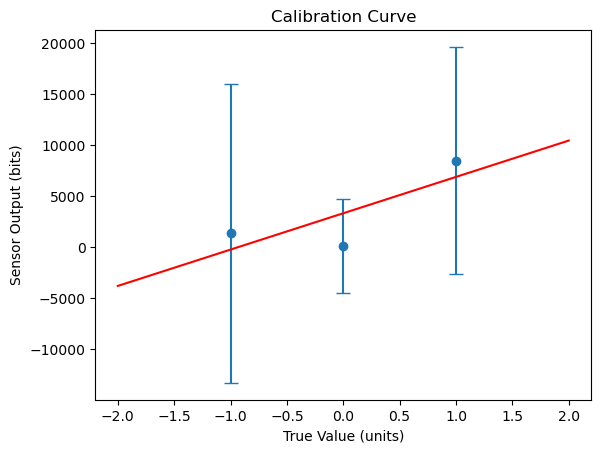

In [7]:
#Fit the calibration curve and plot the curve

slope, intercept, r_value, p_value, std_err = stats.linregress(true_values, mean_sensor_readings) 

fit_x = np.array((min(true_values)-1, max(true_values)+1))
fit_y = fit_x*slope+intercept

plt.figure()
plt.title('Calibration Curve')
plt.xlabel('True Value (units)')
plt.ylabel('Sensor Output (bits)')
plt.errorbar(true_values,mean_sensor_readings, yerr = std_sensor_readings, fmt='None', capsize=5)
plt.scatter(true_values,mean_sensor_readings)
plt.plot(fit_x,fit_y, 'r')

plt.show()


### Bland-Altman Analysis

Bland-Altman plots, or Mean-Difference plots are a tool that allow you to examine the agreement between two interventions or methods of measurement. This is particularly useful when you have a "gold-standard" measurement to which you are comparing.

When creating a Bland-Altman plot, you will have two sets of data:
- Gold-Standard Data
- Experimental Data

You use these inputs to create two additional quantities:
- The mean of the Gold-Standard and Experimental data
- The difference of the Gold-Standard and experimental data

The mean and difference are calculated for each observation in the original dataset. Three subsequent values are also computed to help structure the plot:
- The Mean of the Difference data
- The Standard Deviation of the Difference data
- The 95% limit of agreement (1.96*STD)

The Mean of the difference +/- the 95% limits of agreement are drawn on the figure as horizontal lines. 


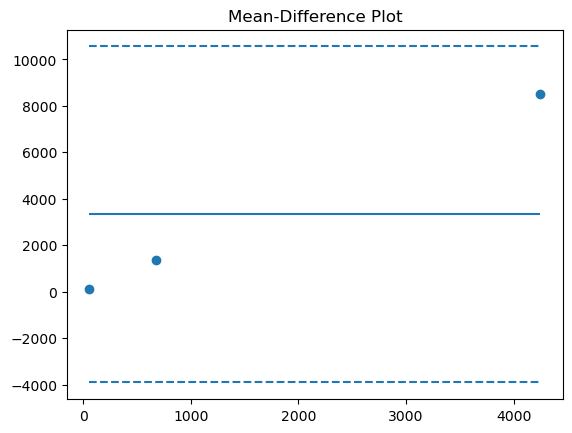

[  57.895 4248.095  680.15 ]
[ 115.79 8494.19 1362.3 ]


In [8]:
# Bland-Altman Plot Creation

# Stack Data into an array with both the sensor readings and true values
# vstack stacks vertically, the resultant array will have 2 rows and N columns, where N is the number of readings you took
data = np.vstack((mean_sensor_readings, true_values))

mean_vals = np.mean(data, axis=0)
diff_vals = data[0,:] - data[1,:]

mean_diff = np.mean(diff_vals)
limits_of_agreement = 1.96*np.std(diff_vals)

plt.figure()
plt.title('Mean-Difference Plot')
plt.scatter(mean_vals, diff_vals)
plt.hlines(mean_diff, xmin=min(mean_vals), xmax=max(mean_vals))
plt.hlines(mean_diff+limits_of_agreement, xmin=min(mean_vals), xmax=max(mean_vals), linestyles='dashed')
plt.hlines(mean_diff-limits_of_agreement, xmin=min(mean_vals), xmax=max(mean_vals), linestyles='dashed')
plt.show()

print(mean_vals)
print(diff_vals)